As a text, I will use the page on Data Science from Wikipedia:

In [3]:
url = 'https://en.wikipedia.org/wiki/Data_science'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

First step in every data science process is getting the data. We will use requests library to do that:

In [4]:
import requests
#.content
#    生（0,1）のデータの受け皿
#       .decode('utf-8')
#           utf-8で人間が読める文字に変換
text = requests.get(url,headers=headers).content.decode('utf-8')
#text[:1000]
#   最初の1文字目から1,000文字目までを画面に表示
print(text[:1000])


<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Data science - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-

Step 2: Transforming the Data
The next step is to convert the data into the form suitable for processing. In our case, we have downloaded HTML source code from the page, and we need to convert it into plain text.

There are many ways this can be done. We will use BeautifulSoup, a popular Python library for parsing HTML. BeautifulSoup allows us to target specific HTML elements, so we can focus on the main article content from Wikipedia and reduce some navigation menus, sidebars, footers, and other irrelevant content (though some boilerplate text may still remain).

First, we need to install the BeautifulSoup library for HTML parsing:
In our case私たちの場合
plain text単純なテキスト
parsing解析する

In [5]:
import sys
#!
#   コマンドに書くこと
#{sys.executable}
#   これを使うとpython3.11.8にインストールの指定
#pip
#   ライブラリのインストールコマンド
!{sys.executable} -m pip install beautifulsoup4


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from bs4 import BeautifulSoup

# Parse the HTML content
soup = BeautifulSoup(text, 'html.parser')

#1000文字までのやつに隠れている
content = soup.find('div', class_='mw-parser-output')

def clean_wikipedia_content(content_node):
    #Remove common non-article elements from a Wikipedia content node.
    # Strip jump links, navboxes, reference lists/superscripts, edit sections, TOC, sidebars, etc.
    selectors = [
        '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar',
    ]
    #selectorsからベルトコンベアで一個ずつ流す
    for selector in selectors:
        #もってきた生のデータからselectorsの条件を探してelにいれる
        for el in content_node.select(selector):
            #.decompose
            #   削除する
            el.decompose()

if content:
    # Clean the content node to better approximate article text only.
    clean_wikipedia_content(content)
    ##### def clean_wikipedia_content

    #<p>Pythonは、<b>プログラミング言語</b>
    # </p>の<p><b></b></p>などを取り除いてテキストだけにする。
    text = content.get_text(separator=' ', strip=True)
    print(text[:1000])
else:
    print("Could not find main content. Using full page text.")
    text = soup.get_text(separator=' ', strip=True)
    print(text[:1000])

Field of study to extract knowledge from data The existence of Comet NEOWISE (here depicted as a series of red dots) was discovered by analyzing astronomical survey data acquired by a space telescope , the Wide-field Infrared Survey Explorer . Data science is an interdisciplinary academic field that uses statistics , scientific computing , scientific methods , processing, scientific visualization , algorithms , and systems to extract or extrapolate knowledge from potentially noisy, structured , or unstructured data . Data science plays a critical role in modern decision-making by enabling organizations to extract actionable insights from large and complex datasets. Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine). Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession. Data science is "a concept to

The most important step is to turn our data into some form from which we can draw insights. In our case, we want to extract keywords from the text, and see which keywords are more meaningful.

We will use Python library called RAKE for keyword extraction. First, let's install this library in case it is not present:

from which先行詞から
insights核心
draw引き出す
extract抽出する
hich keywords are more meaningful疑問代名詞
in case it is not presentそれが存在しなかったら

In [ ]:
import sys
!{sys.executable} -m pip install nlp_rake



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


The main functionality is available from Rake object, which we can customize using some parameters. In our case, we will set the minimum length of a keyword to 5 characters, minimum frequency of a keyword in the document to 3, and maximum number of words in a keyword - to 2. Feel free to play around with other values and observe the result.

, which無視してok
set設定する
5 characters5文字
frequency出現回数
setAtoB AをBに設定する
word単語
Feel free to気軽にして
play around withおもちゃにして遊ぶ
values数値

In [ ]:
#nlp_rakeは型の道具箱
#RAKEは文章の中から、どれが一番重要かを勝手に計算して、勝手にランキング順に並べる
#点数の基準
#たくさんの言葉とセットで使われているフレーズは点数が高くなる
#その単語が文章中に何回登場するか
import nlp_rake
#.Rakeは頭文字が大文字だからクラスの一つ、型の設定
extractor = nlp_rake.Rake(max_words=2,min_freq=3,min_chars=5)
#.apply()はメソッド、適用するということ
#extractorが主語
res = extractor.apply(text)
#Jupiter特有の技、printを書かなくても画面表示
res

[('data scientist', 4.0),
 ('sexiest job', 4.0),
 ('21st century', 4.0),
 ('statistical learning', 4.0),
 ('big data', 4.0),
 ('data science', 3.9),
 ('computer science', 3.9),
 ('information science', 3.809090909090909),
 ('^ davenport', 3.8),
 ('cloud computing', 3.75),
 ('data analysis', 3.7),
 ('science', 1.9),
 ('analysis', 1.7),
 ('statistics', 1.2666666666666666),
 ('processing', 1.25),
 ('thomas', 1.2),
 ('field', 1.0),
 ('techniques', 1.0),
 ('education', 1.0),
 ('communications', 1.0),
 ('chikio', 1.0),
 ('bibcode', 1.0)]

We obtained a list terms together with associated degree of importance. As you can see, the most relevant disciplines, such as machine learning and big data, are present in the list at top positions.

terms単語
togetherまとめて
degree強さ
We obtained [a list of terms (together)] with [associated degree of importance].
togetherは副詞で詳細的な感じで添えられている
obtainAwithB AとBを手に入れる
most relevant最も関連性がある
disciplines分野
As you can seeご覧の通り
 the most relevant disciplines, [such as machine learning and big data,] are present in the list at top positions.


Step 4: Visualizing the Result
People can interpret the data best in the visual form. Thus it often makes sense to visualize the data in order to draw some insights. We can use matplotlib library in Python to plot simple distribution of the keywords with their relevance:
it often makes sense to普通は～
in order to draw some insights核心を引き出すために
distribution分布

In [10]:
import sys
!{sys.executable} -m pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 222.6 kB/s eta 0:00:01
     ---------------------- --------------- 30.7/52.8 kB 220.2 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 273.1 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ----------------------------------- -- 112.6/121.0 kB 3.3 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 2.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.4/8.2 MB 11.6 MB/s eta 0:00:01
   ---- ----------------------------------- 0.9/8.2 MB 9.1 MB/s eta 0:00:01
   -------- ------------------------------- 1.7/8.2 MB 11.9 MB/s eta 0:00:01
   ----------- ----


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


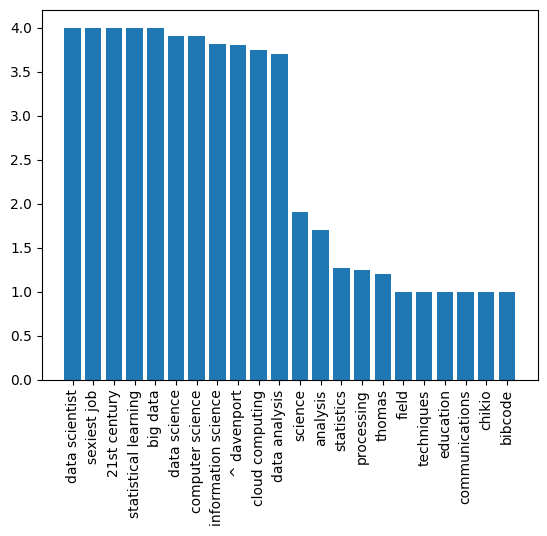

In [ ]:
import matplotlib.pyplot as plt

#pair_list=('data scientist', 4.0)だからわかりやすくpair_listの名前にされている
def plot(pair_list):

    #zip(*)は要素をパカンと半分に割って、2つの箱（k と v）に分ける
    k,v = zip(*pair_list)

    #plt.bar( X軸（横軸）, Y軸（縦軸） )
    #range(len(k))
    #    棒を横に何本、どこに並べるか
    plt.bar(range(len(k)),v)

    #.xticks()は図にネームプレートをつける
    #   plt.xticks( 【どこに】, 【何を】, 【どんな向きで】 )
    plt.xticks(range(len(k)),k,rotation='vertical')
    plt.show()

plot(res)

There is, however, even better way to visualize word frequencies - using Word Cloud. We will need to install another library to plot the word cloud from our keyword list.

plot図にする

In [12]:
import sys
!{sys.executable} -m pip install wordcloud

   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   ----- --------------------------------- 41.0/306.1 kB 653.6 kB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 2.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


WordCloud object is responsible for taking in either original text, or pre-computed list of words with their frequencies, and returns an image, which can then be displayed using matplotlib

pre-computed　pre- は「あらかじめ」
is responsible for役割を持つ
taking in中に取り込む
thenそのあと

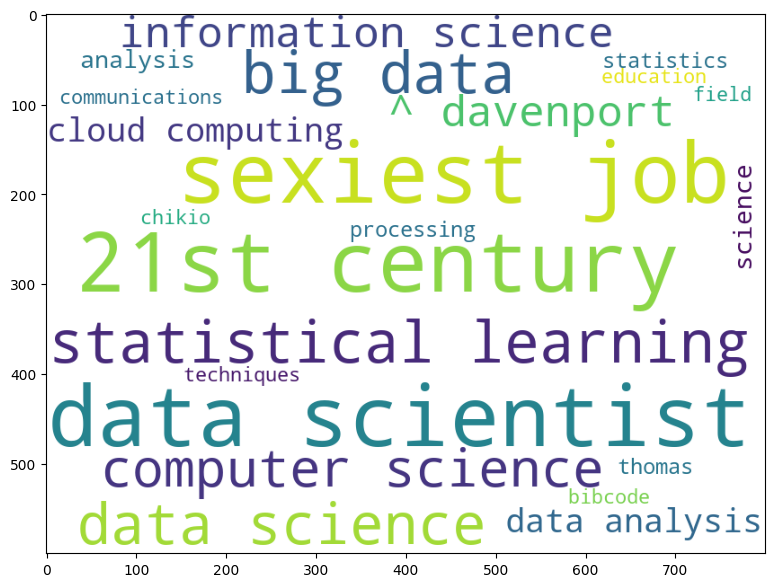

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(background_color='white',width=800,height=600)

#plt.figure()
#   新しい画用紙を作成
#       figsize=(15,7)
#           画用紙のサイズ
plt.figure(figsize=(15,7))
#generate_from_frequencies
#   頻度から画像を生成する
#       { k:v for k,v in res }
#           resからk,vだった型をk:vに一つ一つしていく
#               .imshow()
#                   グラフでなく画面に映し出しなさい
plt.imshow(wc.generate_from_frequencies({ k:v for k,v in res }))

We can also pass in the original text to WordCloud - let's see if we are able to get similar result

#pass inAtoB AをBに手渡す

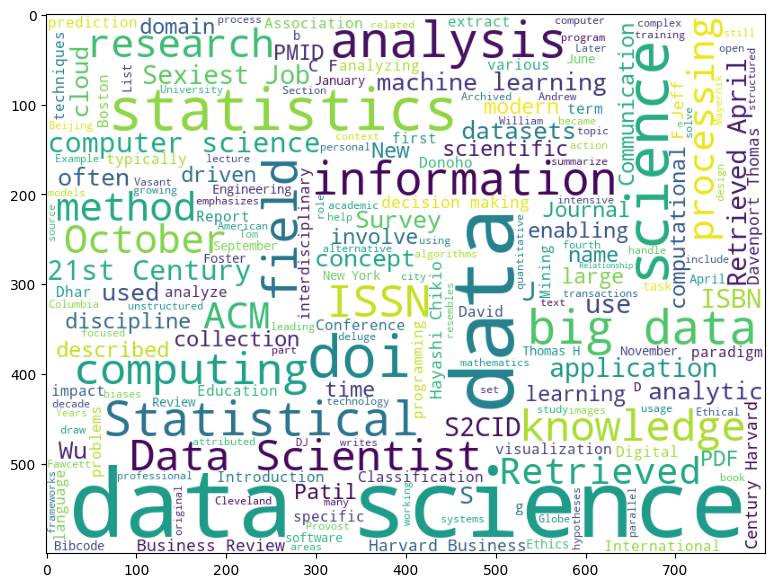

In [14]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(text))

In [ ]:
#wc.generate(text)
#   裏でtextを読み込んで画像を生成
#       .to_file('images/ds_wordcloud.png')
#           画像ファイルとして保存
wc.generate(text).to_file('images/ds_wordcloud.png')

: 

You can see that word cloud now looks more impressive, but it also contains a lot of noise (eg. unrelated words such as Retrieved on). Also, we get fewer keywords that consist of two words, such as data scientist, or computer science. This is because RAKE algorithm does much better job at selecting good keywords from text. This example illustrates the importance of data pre-processing and cleaning, because clear picture at the end will allow us to make better decisions.

In this exercise we have gone through a simple process of extracting some meaning from Wikipedia text, in the form of keywords and word cloud. This example is quite simple, but it demonstrates well all typical steps a data scientist will take when working with data, starting from data acquisition, up to visualization.

In our course we will discuss all those steps in detail.

You can see that...ということがわかるよね
demonstrate wellよく示している
but it demonstrates well all typical steps [a data scientist will take] when working with data, starting from data acquisition, up to visualization.
starting from A, up to B Aから始まってBに至る
acquisition取得
work with扱う
demonstrate証明する
take step挑戦する
, starting from...そして、、から始まって
